<a href="https://colab.research.google.com/github/Gokul-k11/data-science/blob/Diamond-Price-Analysis/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diamond Price Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('diamonds')
print(df.head(5))

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


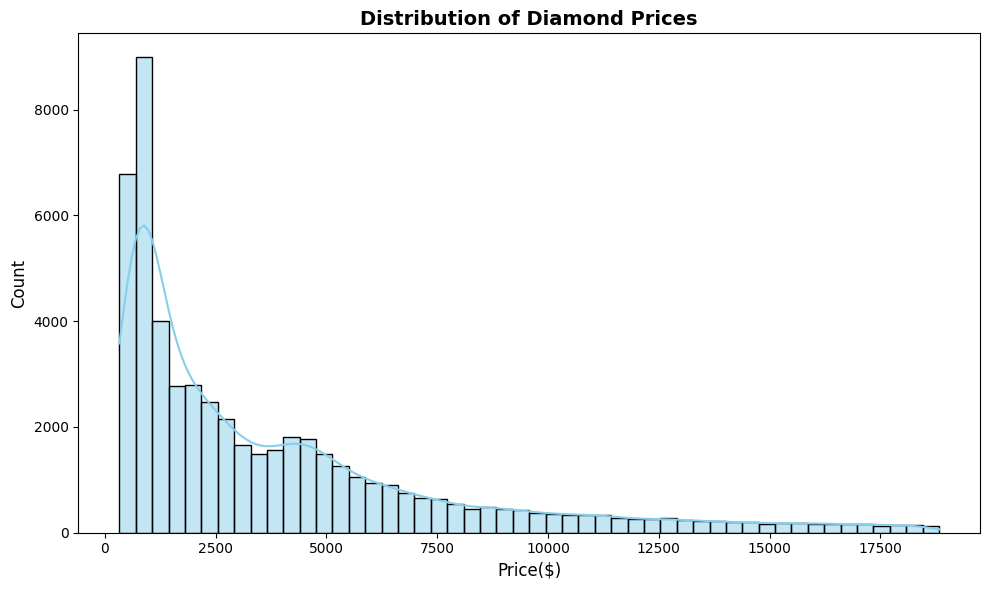

In [ ]:
#price distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='price', bins=50, kde=True, color='skyblue')
plt.title('Distribution of Diamond Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

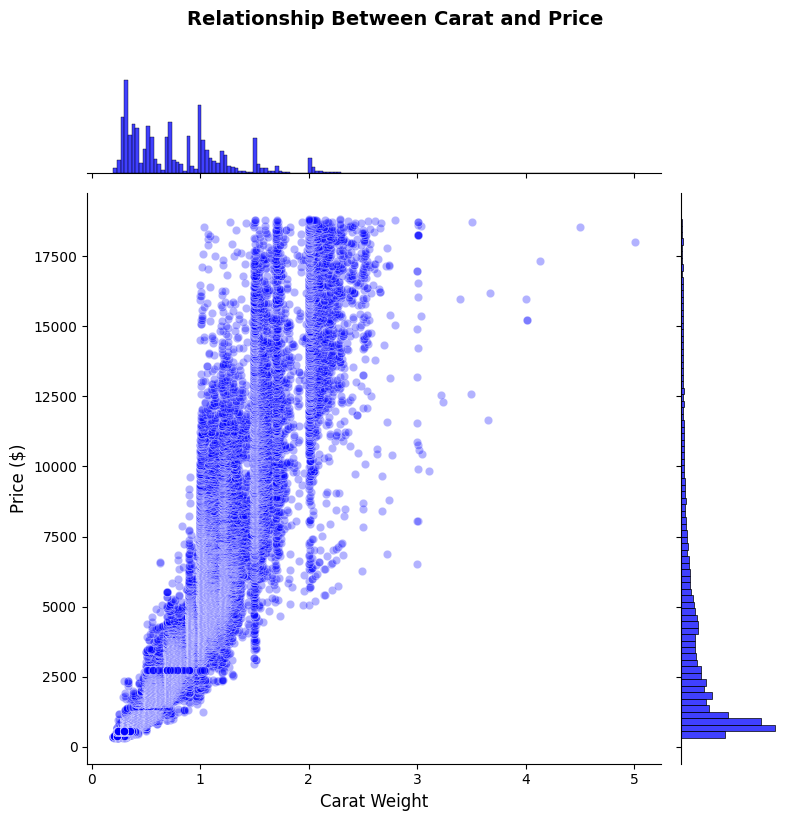

In [ ]:
#relationship between carat and price
g = sns.jointplot(data=df,x='carat',y='price',kind='scatter',alpha=0.3,height=8,color='blue')
g.fig.suptitle('Relationship Between Carat and Price', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels('Carat Weight', 'Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_587/267067611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='cut',y='price',order=cut_order,palette='Blues')


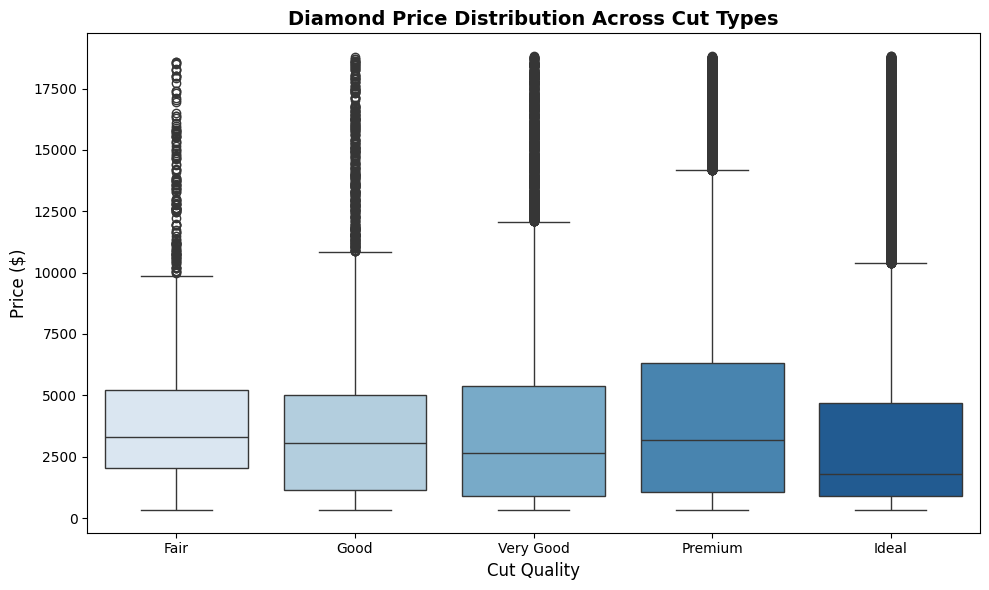

In [ ]:
plt.figure(figsize=(10, 6))
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
sns.boxplot(data=df,x='cut',y='price',order=cut_order,palette='Blues')
plt.title('Diamond Price Distribution Across Cut Types', fontsize=14, fontweight='bold')
plt.xlabel('Cut Quality', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

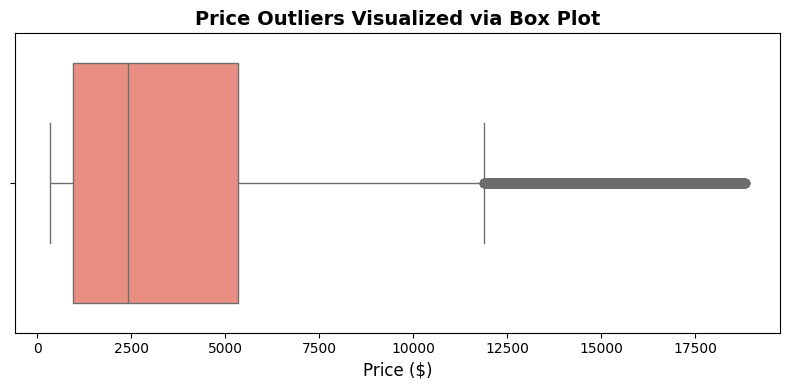

Upper Bound for Price Outliers: $11,885.62
Number of Price Outliers Detected: 3,540
Percentage of Dataset: 6.56%


In [ ]:
#price outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['price'], color='salmon')
plt.title('Price Outliers Visualized via Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()
plt.show()
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
lower_bound = Q1 - (1.5 * IQR)
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Upper Bound for Price Outliers: ${upper_bound:,.2f}")
print(f"Number of Price Outliers Detected: {len(outliers):,}")
print(f"Percentage of Dataset: {(len(outliers) / len(df)) * 100:.2f}%")

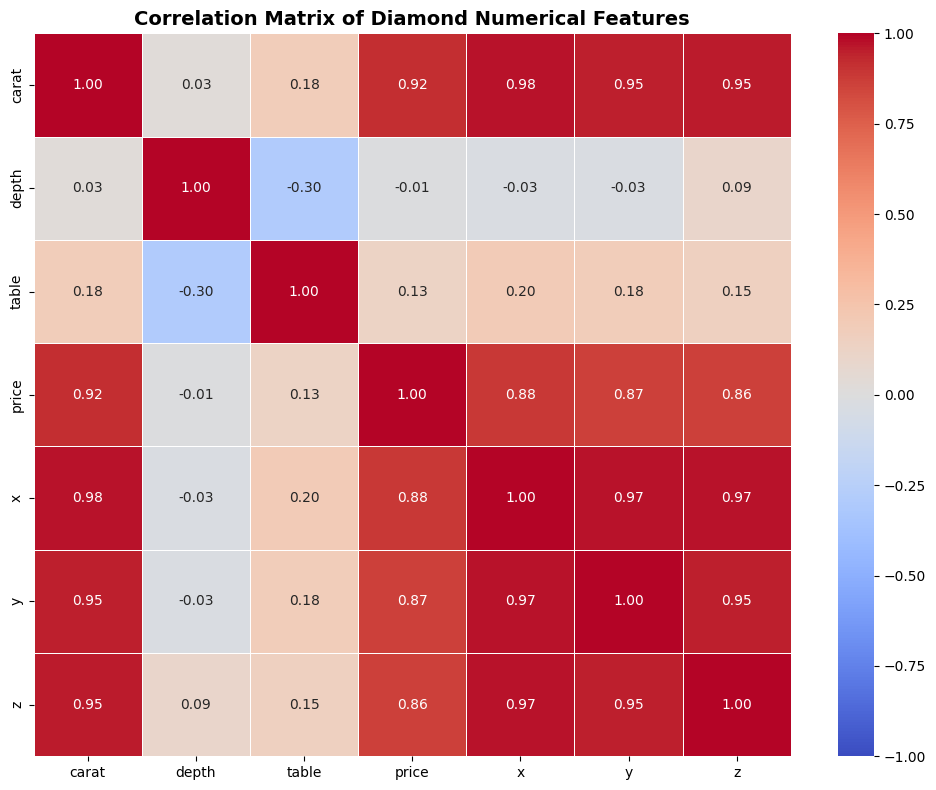

In [ ]:
#correlations among numerical features.
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',vmin=-1,vmax=1,linewidths=0.5)
plt.title('Correlation Matrix of Diamond Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()